In [1]:
import pandas as pd


In [3]:
df = pd.read_csv('daily_coffee_sales.csv', parse_dates=["date"], dayfirst=True)
df.head()

,date,sales
0,2024-01-01,200
1,2024-01-02,205
2,2024-01-03,198
3,2024-01-04,202
4,2024-01-05,189


In [5]:
df.shape

(365, 2)

set date as index

In [6]:
df.set_index("date", inplace=True)

In [7]:
df.index

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10',
               ...
               '2024-12-21', '2024-12-22', '2024-12-23', '2024-12-24',
               '2024-12-25', '2024-12-26', '2024-12-27', '2024-12-28',
               '2024-12-29', '2024-12-30'],
              dtype='datetime64[ns]', name='date', length=365, freq=None)

frequency

In [8]:
df = df.asfreq("D")

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

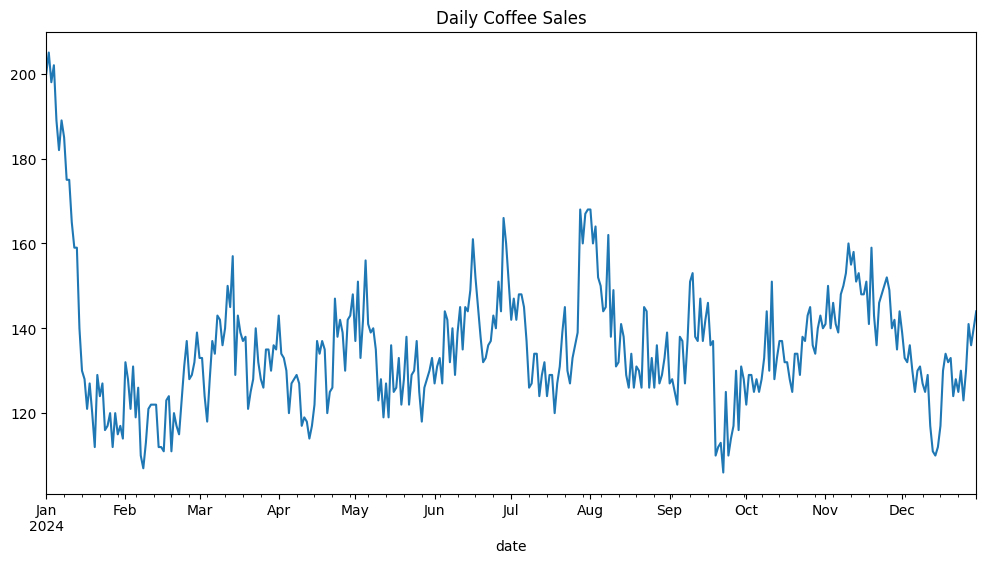

In [10]:
df["sales"].plot(title="Daily Coffee Sales", figsize=(12, 6))
plt.show()

check for stationary data: mean is unchanged, variance is constant

for this we have ADFuller test

In [12]:
from statsmodels.tsa.stattools import adfuller


In [14]:
result_adf = adfuller(df["sales"])
result_adf

(np.float64(-5.5204890619155105),
 np.float64(1.882499058910748e-06),
 1,
 363,
 {'1%': np.float64(-3.448493650810824),
  '5%': np.float64(-2.8695352280356556),
  '10%': np.float64(-2.5710293341377715)},
 np.float64(2396.2913199754635))

find the value of p and q for this we have pacf  and acf plot

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf

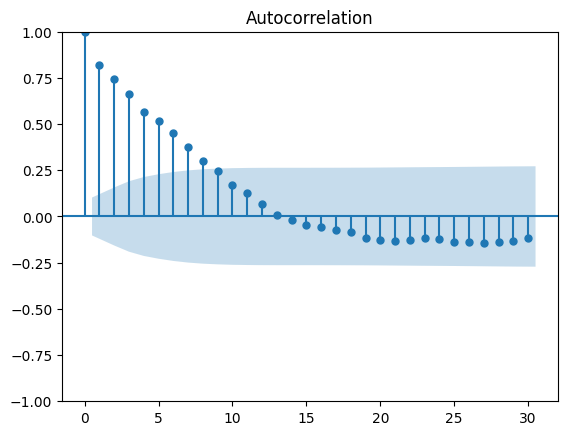

In [16]:
plot_acf(df["sales"], lags=30)
plt.show()

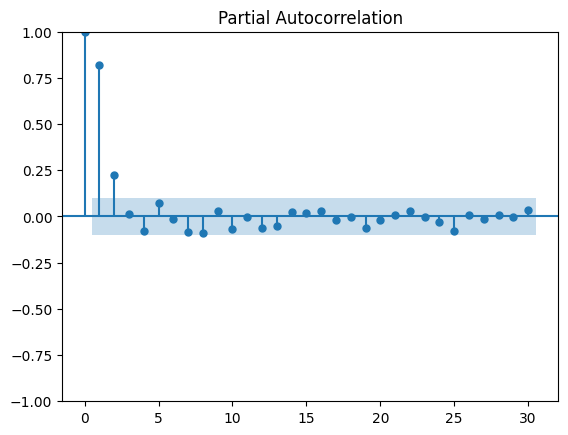

In [17]:
plot_pacf(df["sales"], lags=30)
plt.show()

ARIMA model

In [18]:
from statsmodels.tsa.arima.model import ARIMA


In [19]:
arima_model = ARIMA(df["sales"], order=(3,0,2))
arima_result = arima_model.fit()

C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  365
Model:                 ARIMA(3, 0, 2)   Log Likelihood               -1267.322
Date:                Sun, 17 May 2026   AIC                           2548.644
Time:                        21:17:42   BIC                           2575.943
Sample:                    01-01-2024   HQIC                          2559.493
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        138.3325      4.648     29.760      0.000     129.222     147.443
ar.L1         -0.2228      0.204     -1.094      0.274      -0.622       0.176
ar.L2          0.7224      0.165      4.391      0.0

forecast for next 7 days

In [23]:
forecast = arima_result.get_forecast(steps=7)
forecast_mean = forecast.predicted_mean
confidence_intervals = forecast.conf_int()
confidence_intervals

,lower sales,upper sales
2024-12-31,126.825431,157.299262
2025-01-01,124.694506,160.338311
2025-01-02,121.701442,162.465267
2025-01-03,119.203424,164.452644
2025-01-04,117.666683,165.796070
2025-01-05,115.814588,167.018454
2025-01-06,114.671010,167.983515


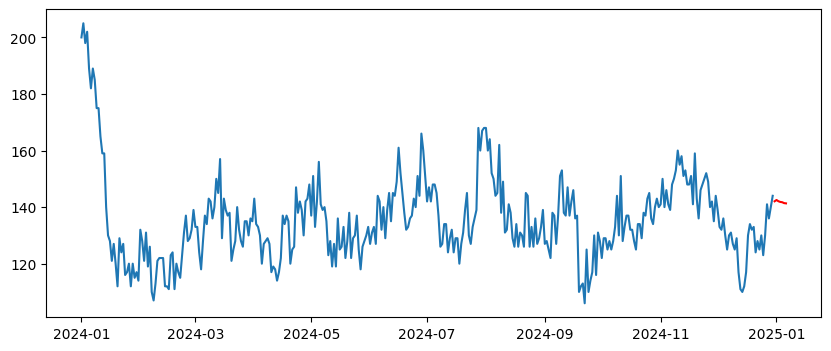

In [25]:
plt.figure(figsize=(10,4))
plt.plot(df["sales"], label = "Acutal Sales")
plt.plot(forecast_mean, label = "Forecasted Values", color='red')
plt.show()